In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix,make_scorer, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,roc_curve,auc
import sklearn.metrics as skm
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.svm import SVC
import seaborn as sns
import xgboost as xgb

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset,random_split,DataLoader
import time

# Data Preparation

In [3]:
df=pd.read_csv("LUBS5990M_courseworkData_2324.csv")

In [4]:
df.replace(['Y','N'],[1,0],inplace=True)

In [5]:
def log_t(x):
    return np.log10(x+1)

In [6]:
df.loc[:,'priceUSD']=df.loc[:,'priceUSD'].apply(log_t)

In [7]:
df.loc[:,'coinNum']=df.loc[:,'coinNum'].apply(log_t)

In [8]:
df.loc[:,'teamSize']=df.loc[:,'teamSize'].apply(np.sqrt)

In [9]:
def count_digit(x):
    x=str(x)
    if '.' in x:
        x=x.split('.')
        x=x[0]
        if(len(x)==2):
            return True
    return False

In [10]:
df_distPer=df[df['distributedPercentage']>1].distributedPercentage
df_distPer=df_distPer.apply(count_digit)
distPer_drop=df_distPer[df_distPer==False].index
distPer_rescale=df_distPer[df_distPer==True].index
df.drop(labels=distPer_drop,inplace=True)
df.loc[distPer_rescale,'distributedPercentage']=df.loc[distPer_rescale,'distributedPercentage']/100

In [11]:
df.shape

(2761, 16)

In [12]:
num_col=[4,5,9,13,15]
num_col=df.columns[num_col].to_list()

In [13]:
x=pd.Series(df.platform.unique())
y=x.str.contains('eth',case=False)
eth=x[y[y==True].index].values
df.platform.replace(eth,'Ethereum',inplace=True)

In [14]:
def categorical_analysis(df1,x):
    cat_df1=pd.DataFrame(df1.groupby(by=x).success.sum()*100/df1.groupby(by=x).success.count())
    cat_df2=pd.DataFrame(df1.groupby(by=x).success.count())
    cat_df1=cat_df1.rename(columns={'success':'rate'})
    cat_df1=cat_df1.merge(cat_df2,on=x)
    cat_df1=cat_df1.rename(columns={'success':'count'})
    return cat_df1

In [15]:
platform_combine=categorical_analysis(df,'platform').sort_values(by='count',ascending=False)
platform_replace1=platform_combine[(platform_combine['count']<2) & (platform_combine['rate']!=100)].index
df['platform'].replace(platform_replace1,'Others1',inplace=True)
platform_replace2=platform_combine[(platform_combine['count']<3) & (platform_combine['rate']!=100)].index
df['platform'].replace(platform_replace2,'Others2',inplace=True)

In [16]:
countryRegion_correction={'Curaçao':'Curacao','México':'Mexico','india':'India','usa':'USA','SINGAPORE':'Singapore'}
df['countryRegion'].replace(countryRegion_correction,inplace=True)

In [17]:
cR_combine=categorical_analysis(df,'countryRegion').sort_values(by='count',ascending=False)
cR_replace1=cR_combine[(cR_combine['count']<7) & (cR_combine['rate']!=100)].index
df['countryRegion'].replace(cR_replace1,'Others1',inplace=True)
cR_replace2=cR_combine[(cR_combine['count']<6) & (cR_combine['rate']==100)].index
df['countryRegion'].replace(cR_replace2,'Others2',inplace=True)

In [18]:
categorical_analysis(df,'countryRegion').sort_values(by='count',ascending=False)

,rate,count
countryRegion,,
Singapore,48.881789,313
USA,27.609428,297
UK,36.842105,285
Estonia,46.596859,191
Switzerland,47.482014,139
Russia,37.681159,138
Others1,17.431193,109
Cayman Islands,52.238806,67
Germany,32.786885,61


In [19]:
df['priceUSD_null']=df.priceUSD.isna()
df['teamSize_null']=df.teamSize.isna()

In [20]:
df_f=pd.get_dummies(df,columns=['platform','countryRegion'])
df_f.drop(columns=['ID','brandSlogan','startDate','endDate'],inplace=True)

In [21]:
df_f.shape

(2761, 127)

# Modelling

In [22]:
def preprocess(df):
    X=df[df.columns[1:]]
    Y=df[df.columns[0]]
    X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.20, random_state=42)
    scaler = StandardScaler()
    X_train[num_col] = scaler.fit_transform(X_train[num_col])
    X_test[num_col] = scaler.transform(X_test[num_col])
    X_train=X_train.fillna(value={'priceUSD':-1,'teamSize':-1})
    X_test=X_test.fillna(value={'priceUSD':-1,'teamSize':-1})
    return X_train, X_test, Y_train, Y_test

In [23]:
def my_roc_auc(model,X_test,Y_test): 
    Y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(Y_test, Y_prob)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='grey', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.show()

In [31]:
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score, zero_division=0.0),
    'recall': make_scorer(recall_score, zero_division=0.0),
    'f1': make_scorer(f1_score, zero_division=0.0),
    'auc': make_scorer(roc_auc_score)
}

## RFC

In [127]:
def my_RFC(df):
    X_train, X_test, Y_train, Y_test = preprocess(df)
    model=RandomForestClassifier(max_features='log2',oob_score=True,min_samples_leaf=7,n_estimators=500,class_weight={0:1,1:1.5})
    model=model.fit(X_train,Y_train)
    Y_pred=model.predict(X_test)
    print("OOB Score: ",model.oob_score_)
    print("Accuracy: ",skm.accuracy_score(Y_test,Y_pred))
    print("Confusion Matrix:\n",confusion_matrix(Y_test,Y_pred))
    print("PRFC:\n",skm.precision_recall_fscore_support(Y_test,Y_pred))
    my_roc_auc(model,X_test,Y_test)

OOB Score:  0.6521739130434783
Accuracy:  0.7070524412296564
Confusion Matrix:
 [[273  81]
 [ 81 118]]
PRFC:
 (array([0.77118644, 0.59296482]), array([0.77118644, 0.59296482]), array([0.77118644, 0.59296482]), array([354, 199], dtype=int64))


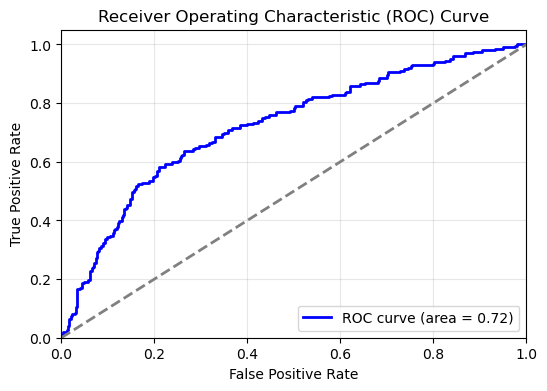

In [128]:
my_RFC(df_f)

In [106]:
X_train, X_test, Y_train, Y_test = preprocess(df_f)
param_grid = {
'n_estimators': [100, 200, 500, 1000],
'max_depth': [10, 20, None],
'min_samples_leaf': [1, 2, 4, 7, 10],
'max_features': ['sqrt', 'log2', 20, 50, 100],
'class_weight': ['balanced', {0:1,1:1.25}, {0:1,1:1.5}, {0:1,1:2}]
}
rfc = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(
estimator=rfc,
param_grid=param_grid,
cv=5,
verbose=2,
n_jobs=-1  # Use all available CPU cores for faster processing
)
grid_search.fit(X_train, Y_train)
print("Best Parameters: ", grid_search.best_params_)
print("Best Cross-Validation Score: ", grid_search.best_score_)
best_model = grid_search.best_estimator_
print("Test Set:")
Y_pred=best_model.predict(X_test)
print("Accuracy: ",skm.accuracy_score(Y_test,Y_pred))
print("Confusion Matrix:\n",confusion_matrix(Y_test,Y_pred))
print("PRFC:\n",skm.precision_recall_fscore_support(Y_test,Y_pred))

Fitting 5 folds for each of 1200 candidates, totalling 6000 fits
Best Parameters:  {'class_weight': {0: 1, 1: 1.25}, 'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 7, 'n_estimators': 500}
Best Cross-Validation Score:  0.6689219277454572
Test Set:
Accuracy:  0.7034358047016275
Confusion Matrix:
 [[307  47]
 [117  82]]
PRFC:
 (array([0.7240566 , 0.63565891]), array([0.86723164, 0.4120603 ]), array([0.78920308, 0.5       ]), array([354, 199], dtype=int64))


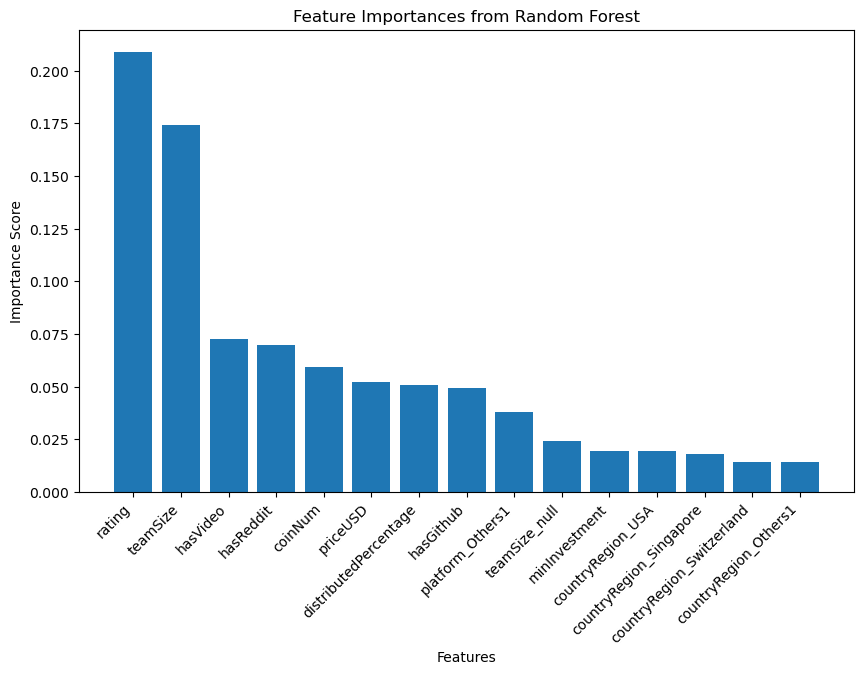

In [107]:
importances = best_model.feature_importances_
feature_names = X_train.columns
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)
importance_plot=importance_df.head(15)
plt.figure(figsize=(10, 6))
plt.bar(importance_plot['Feature'], importance_plot['Importance'])
plt.title('Feature Importances from Random Forest')
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.show()

## SVC

### Poly

In [132]:
def my_SVC_poly(df,c,d,cw='balanced'):
    X_train, X_test, Y_train, Y_test = preprocess(df)
    model=SVC(C=c,kernel='poly',degree=d,class_weight=cw,probability=True)
    model=model.fit(X_train,Y_train)
    Y_pred=model.predict(X_test)
    print("Accuracy: ",skm.accuracy_score(Y_test,Y_pred))
    print("Confusion Matrix:\n",confusion_matrix(Y_test,Y_pred))
    print("PRFC:\n",skm.precision_recall_fscore_support(Y_test,Y_pred))
    my_roc_auc(model,X_test,Y_test)

Accuracy:  0.6907775768535263
Confusion Matrix:
 [[264  90]
 [ 81 118]]
PRFC:
 (array([0.76521739, 0.56730769]), array([0.74576271, 0.59296482]), array([0.75536481, 0.57985258]), array([354, 199], dtype=int64))


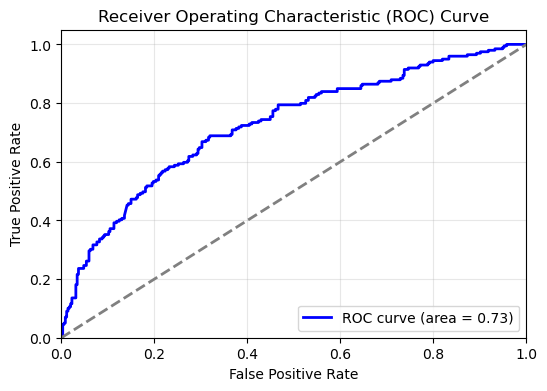

In [137]:
my_SVC_poly(df_f,5,1,{0:1,1:1.3})

In [90]:
X_train, X_test, Y_train, Y_test = preprocess(df_f)
param_grid = {
'C': [0.1, 0.5, 1, 5, 10, 20, 50],
'degree': [1,2,3,4,5],
'class_weight': ['balanced', {0:1,1:1.25}, {0:1,1:1.5}, {0:1,1:2}]
}
model = SVC(kernel='poly')
grid_search = GridSearchCV(model, param_grid, cv=5)
grid_search.fit(X_train, Y_train)
print("Best Parameters: ", grid_search.best_params_)
print("Best Score: ", grid_search.best_score_)
best_model = grid_search.best_estimator_
print("Test Set:")
Y_pred=best_model.predict(X_test)
print("Accuracy: ",skm.accuracy_score(Y_test,Y_pred))
print("Confusion Matrix:\n",confusion_matrix(Y_test,Y_pred))
print("PRFC:\n",skm.precision_recall_fscore_support(Y_test,Y_pred))

Best Parameters:  {'C': 5, 'class_weight': {0: 1, 1: 1.25}, 'degree': 1}
Best Score:  0.6625850340136055
Test Set:
Accuracy:  0.6980108499095841
Confusion Matrix:
 [[269  85]
 [ 82 117]]
PRFC:
 (array([0.76638177, 0.57920792]), array([0.75988701, 0.5879397 ]), array([0.76312057, 0.58354115]), array([354, 199], dtype=int64))


### RBF

In [69]:
def my_SVC_rbf(df,c=1,g=0.01):
    X_train, X_test, Y_train, Y_test = preprocess(df)
    model=SVC(C=c,kernel='rbf',gamma=g,class_weight={0:1,1:1.25},probability=True)
    model=model.fit(X_train,Y_train)
    Y_pred=model.predict(X_test)
    print("Accuracy: ",skm.accuracy_score(Y_test,Y_pred))
    print("Confusion Matrix:\n",confusion_matrix(Y_test,Y_pred))
    print("PRFC:\n",skm.precision_recall_fscore_support(Y_test,Y_pred))
    my_roc_auc(model,X_test,Y_test)

Accuracy:  0.6998191681735986
Confusion Matrix:
 [[284  70]
 [ 96 103]]
PRFC:
 (array([0.74736842, 0.59537572]), array([0.80225989, 0.51758794]), array([0.77384196, 0.55376344]), array([354, 199], dtype=int64))


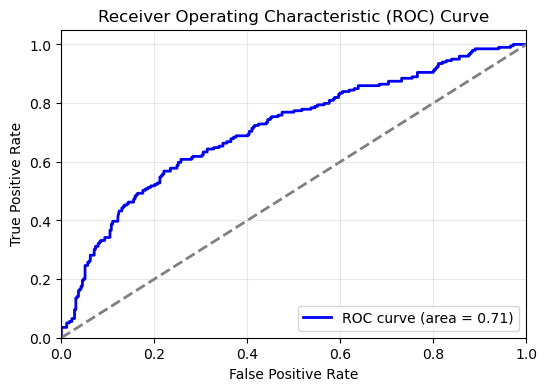

In [70]:
my_SVC_rbf(df_f,1,0.05)

In [34]:
X_train, X_test, Y_train, Y_test = preprocess(df_f)
param_grid = {
    'C': [0.1, 0.4, 0.7, 1, 5, 10, 20, 50],
    'gamma': [0.0001, 0.001, 0.01, 0.05, 0.1],
    'class_weight': ['balanced', {0:1,1:1.25}, {0:1,1:1.5}, {0:1,1:2}]
}
model = SVC(kernel='rbf')
grid_search = GridSearchCV(
    model,
    param_grid=param_grid,
    scoring=scoring,
    refit='f1',  
    cv=5,
    verbose=1)
grid_search.fit(X_train, Y_train)
print("Best Parameters: ", grid_search.best_params_)
print("Best Score: ", grid_search.best_score_)
best_model = grid_search.best_estimator_
print("Test Set: ")
Y_pred=best_model.predict(X_test)
print("Accuracy: ",skm.accuracy_score(Y_test,Y_pred))
print("Confusion Matrix:\n",confusion_matrix(Y_test,Y_pred))
print("PRFC:\n",skm.precision_recall_fscore_support(Y_test,Y_pred))

Fitting 5 folds for each of 160 candidates, totalling 800 fits
Best Parameters:  {'C': 0.7, 'class_weight': {0: 1, 1: 2}, 'gamma': 0.001}
Best Score:  0.59377641219712
Test Set: 
Accuracy:  0.6075949367088608
Confusion Matrix:
 [[187 167]
 [ 50 149]]
PRFC:
 (array([0.78902954, 0.47151899]), array([0.52824859, 0.74874372]), array([0.63282572, 0.57864078]), array([354, 199], dtype=int64))


In [35]:
results_df = pd.DataFrame(grid_search.cv_results_)

In [37]:
results_df.columns

Index(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time',
       'param_C', 'param_class_weight', 'param_gamma', 'params',
       'split0_test_accuracy', 'split1_test_accuracy', 'split2_test_accuracy',
       'split3_test_accuracy', 'split4_test_accuracy', 'mean_test_accuracy',
       'std_test_accuracy', 'rank_test_accuracy', 'split0_test_precision',
       'split1_test_precision', 'split2_test_precision',
       'split3_test_precision', 'split4_test_precision', 'mean_test_precision',
       'std_test_precision', 'rank_test_precision', 'split0_test_recall',
       'split1_test_recall', 'split2_test_recall', 'split3_test_recall',
       'split4_test_recall', 'mean_test_recall', 'std_test_recall',
       'rank_test_recall', 'split0_test_f1', 'split1_test_f1',
       'split2_test_f1', 'split3_test_f1', 'split4_test_f1', 'mean_test_f1',
       'std_test_f1', 'rank_test_f1', 'split0_test_auc', 'split1_test_auc',
       'split2_test_auc', 'split3_test_auc', 'split4_test_a

In [67]:
results_df.loc[(results_df['mean_test_auc']>0.6)& (results_df['mean_test_accuracy']>0.65),['mean_test_auc','mean_test_accuracy']].sort_values(by='mean_test_accuracy', ascending=False)

,mean_test_auc,mean_test_accuracy
68,0.630431,0.667570
29,0.629108,0.667117
8,0.625001,0.667114
9,0.623668,0.666664
146,0.636720,0.666663
48,0.628014,0.665756
28,0.626211,0.665303
7,0.600863,0.665301
87,0.626584,0.664856
125,0.629014,0.664851


In [68]:
results_df.loc[68]

mean_fit_time                                                     0.194565
std_fit_time                                                       0.00329
mean_score_time                                                   0.082347
std_score_time                                                    0.007477
param_C                                                                  1
param_class_weight                                         {0: 1, 1: 1.25}
param_gamma                                                           0.05
params                   {'C': 1, 'class_weight': {0: 1, 1: 1.25}, 'gam...
split0_test_accuracy                                              0.651584
split1_test_accuracy                                              0.658371
split2_test_accuracy                                              0.699095
split3_test_accuracy                                              0.646259
split4_test_accuracy                                               0.68254
mean_test_accuracy       

### Sigmoid

In [91]:
X_train, X_test, Y_train, Y_test = preprocess(df_f)
param_grid = {
    'C': [0.1, 0.4, 0.7, 1, 5, 10, 20, 50],
    'gamma': [0.0001, 0.001, 0.01, 0.05, 0.1],
    'class_weight': ['balanced', {0:1,1:1.25}, {0:1,1:1.5}, {0:1,1:2}]
}
model = SVC(kernel='sigmoid')
grid_search = GridSearchCV(model, param_grid, cv=5)
grid_search.fit(X_train, Y_train)
print("Best Parameters: ", grid_search.best_params_)
print("Best Score: ", grid_search.best_score_)
best_model = grid_search.best_estimator_
print("Test Set: ")
Y_pred=best_model.predict(X_test)
print("Accuracy: ",skm.accuracy_score(Y_test,Y_pred))
print("Confusion Matrix:\n",confusion_matrix(Y_test,Y_pred))
print("PRFC:\n",skm.precision_recall_fscore_support(Y_test,Y_pred))

Best Parameters:  {'C': 0.4, 'class_weight': {0: 1, 1: 1.25}, 'gamma': 0.01}
Best Score:  0.6643960148161828
Test Set: 
Accuracy:  0.6980108499095841
Confusion Matrix:
 [[281  73]
 [ 94 105]]
PRFC:
 (array([0.74933333, 0.58988764]), array([0.79378531, 0.52763819]), array([0.77091907, 0.55702918]), array([354, 199], dtype=int64))


### Undersampling

In [100]:
X_train, X_test, Y_train, Y_test = preprocess(df_f)
rus=RandomUnderSampler(random_state=42)
X_train,Y_train=rus.fit_resample(X_train,Y_train)
param_grid = {
    'C': [0.1, 0.4, 0.7, 1, 5, 10, 20, 50],
    'gamma': [0.0001, 0.001, 0.01, 0.05, 0.1],
    'class_weight': ['balanced', {0:1,1:1.25}, {0:1,1:1.5}, {0:1,1:2}]
}
model = SVC(kernel='rbf')
grid_search = GridSearchCV(model, param_grid, cv=5)
grid_search.fit(X_train, Y_train)
print("Best Parameters: ", grid_search.best_params_)
print("Best Score: ", grid_search.best_score_)
best_model = grid_search.best_estimator_
print("Test Set: ")
Y_pred=best_model.predict(X_test)
print("Accuracy: ",skm.accuracy_score(Y_test,Y_pred))
print("Confusion Matrix:\n",confusion_matrix(Y_test,Y_pred))
print("PRFC:\n",skm.precision_recall_fscore_support(Y_test,Y_pred))

Best Parameters:  {'C': 1, 'class_weight': 'balanced', 'gamma': 0.1}
Best Score:  0.6479525352163942
Test Set: 
Accuracy:  0.6546112115732369
Confusion Matrix:
 [[228 126]
 [ 65 134]]
PRFC:
 (array([0.778157  , 0.51538462]), array([0.6440678 , 0.67336683]), array([0.70479134, 0.583878  ]), array([354, 199], dtype=int64))


### Oversampling

In [101]:
X_train, X_test, Y_train, Y_test = preprocess(df_f)
oversampler=SMOTE()
X_train,Y_train=oversampler.fit_resample(X_train,Y_train)
param_grid = {
    'C': [0.1, 0.4, 0.7, 1, 5, 10, 20, 50],
    'gamma': [0.0001, 0.001, 0.01, 0.05, 0.1],
    'class_weight': ['balanced', {0:1,1:1.25}, {0:1,1:1.5}, {0:1,1:2}]
}
model = SVC(kernel='rbf')
grid_search = GridSearchCV(model, param_grid, cv=5)
grid_search.fit(X_train, Y_train)
print("Best Parameters: ", grid_search.best_params_)
print("Best Score: ", grid_search.best_score_)
best_model = grid_search.best_estimator_
print("Test Set: ")
Y_pred=best_model.predict(X_test)
print("Accuracy: ",skm.accuracy_score(Y_test,Y_pred))
print("Confusion Matrix:\n",confusion_matrix(Y_test,Y_pred))
print("PRFC:\n",skm.precision_recall_fscore_support(Y_test,Y_pred))

Best Parameters:  {'C': 5, 'class_weight': 'balanced', 'gamma': 0.1}
Best Score:  0.6971014492753623
Test Set: 
Accuracy:  0.6473779385171791
Confusion Matrix:
 [[250 104]
 [ 91 108]]
PRFC:
 (array([0.73313783, 0.50943396]), array([0.70621469, 0.54271357]), array([0.71942446, 0.52554745]), array([354, 199], dtype=int64))


## ANN

In [175]:
df_nn=df_f.fillna(value={'priceUSD':-1,'teamSize':-1})
X=df_nn.iloc[:,1:]
Y=df_nn.iloc[:,0]
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.20, random_state=42)
X_train, X_val, Y_train, Y_val = train_test_split(X_train, Y_train, test_size=0.20, random_state=41)

scaler = StandardScaler()
X_train[num_col] = scaler.fit_transform(X_train[num_col])
X_val[num_col] = scaler.transform(X_val[num_col])
X_test[num_col] = scaler.transform(X_test[num_col])

X_train=X_train.fillna(value={'priceUSD':-1,'teamSize':-1})
X_val=X_val.fillna(value={'priceUSD':-1,'teamSize':-1})
X_test=X_test.fillna(value={'priceUSD':-1,'teamSize':-1})

X_train=torch.tensor(X_train.values.astype('float32'))
Y_train=torch.tensor(Y_train.values.astype('float32'))
X_val=torch.tensor(X_val.values.astype('float32'))
Y_val=torch.tensor(Y_val.values.astype('float32'))
X_test=torch.tensor(X_test.values.astype('float32'))
Y_test=torch.tensor(Y_test.values.astype('float32'))

train_dataset = TensorDataset(X_train, Y_train)
val_dataset = TensorDataset(X_val, Y_val)
test_dataset = TensorDataset(X_test, Y_test)
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=4
)
val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=4
)
test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=4
)

In [22]:
class ICO(nn.Module):
    def __init__(self, i,h=[64,16]):
        super(ICO, self).__init__()
        self.input_layer = nn.Linear(i, h[0])
        self.hidden_layers = nn.ModuleList([
            nn.Linear(h[i], h[i+1])
            for i in range(len(h) - 1)])
        self.output_layer = nn.Linear(h[-1], 1)

    def forward(self, x):
        x = F.relu(self.input_layer(x))
        for layer in self.hidden_layers:
            x = F.relu(layer(x))
        x = F.sigmoid(self.output_layer(x))
        return x

In [25]:
class ICO_Dropout(ICO):
    def __init__(self, i, h=[64, 16], dropout_rate=0.5):
        super(ICO_Dropout, self).__init__(i, h)
        self.dropout = nn.Dropout(p=dropout_rate)

    def forward(self, x):
        x = self.dropout(F.relu(self.input_layer(x)))
        
        for layer in self.hidden_layers:
            x = self.dropout(F.relu(layer(x)))
        x = F.sigmoid(self.output_layer(x))
        return x

In [ ]:
model =ICO_Dropout(i=129,h=[64,16],dropout_rate=0.35)
criterion = nn.BCELoss(weight=torch.tensor([2]))
optimizer = optim.Adam(model.parameters(), lr=0.005)

In [ ]:

#model = ICO(129)
model =ICO_Dropout(i=(X_train.shape[1]),h=[64,16],dropout_rate=0.35)
criterion = nn.BCELoss(weight=torch.tensor([2]))
optimizer = optim.Adam(model.parameters(), lr=0.005)

# Set up the device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# --- End of Assumed Setup ---

# Lists to store metrics for plotting later
train_loss_history = []
val_loss_history = []
train_acc_history = []
val_acc_history = []

num_epochs = 10
for epoch in range(num_epochs):
    # --- Training Phase ---
    model.train()  # Set model to training mode
    running_train_loss = 0.0
    correct_train_predictions = 0
    total_train_samples = 0

    #print(f"Starting {epoch}")

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        # Forward pass
        outputs = model(inputs).squeeze()
        loss = criterion(outputs, labels)

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Update metrics
        running_train_loss += loss.item() * inputs.size(0)
        predicted = (outputs > 0.4).float()
        correct_train_predictions += (predicted == labels).sum().item()
        total_train_samples += labels.size(0)

    #print(f"Training {epoch} done")

    avg_train_loss = running_train_loss / total_train_samples
    train_accuracy = correct_train_predictions / total_train_samples
    train_loss_history.append(avg_train_loss)
    train_acc_history.append(train_accuracy*100)

    # --- Validation Phase ---
    model.eval()  # Set model to evaluation mode
    running_val_loss = 0.0
    correct_val_predictions = 0
    total_val_samples = 0

    with torch.no_grad():  # Crucial for validation; disables gradient calculation
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            # Forward pass only
            outputs = model(inputs).squeeze()
            loss = criterion(outputs, labels)

            # Update metrics
            running_val_loss += loss.item() * inputs.size(0)
            predicted = (outputs > 0.5).float()
            correct_val_predictions += (predicted == labels).sum().item()
            total_val_samples += labels.size(0)

    avg_val_loss = running_val_loss / total_val_samples
    val_accuracy = correct_val_predictions / total_val_samples
    val_loss_history.append(avg_val_loss)
    val_acc_history.append(val_accuracy*100)

    # --- Print Epoch Summary ---
    print(f'Epoch [{epoch+1}/{num_epochs}], '
          f'Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy*100:.2f}, '
          f'Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy*100:.2f}')

# After the loop, the metric history lists are populated and ready for plotting.

Epoch [1/10], Train Loss: 1.2627, Train Acc: 59.23, Val Loss: 1.2310, Val Acc: 66.06
Epoch [2/10], Train Loss: 1.2249, Train Acc: 66.48, Val Loss: 1.2175, Val Acc: 67.42


In [ ]:
print(model)

In [ ]:
model.eval()
correct_test_predictions = 0
total_test_samples = 0

with torch.no_grad():  
    all_predicted=[]
    all_labels=[]
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        # Forward pass only
        outputs = model(inputs).squeeze()
        loss = criterion(outputs, labels)

        predicted = (outputs > 0.5).float()
        all_predicted+=predicted
        all_labels+=labels
        correct_test_predictions += (predicted == labels).sum().item()
        total_test_samples += labels.size(0)
print("Accuracy: ",skm.accuracy_score(all_labels,all_predicted))
print("Confusion Matrix:\n",confusion_matrix(all_labels,all_predicted))
print("PRFC:\n",skm.precision_recall_fscore_support(all_labels,all_predicted))

## XGBoost

In [49]:
def my_XGB(df,ne,lr,md,ss,cs,w):
    X_train, X_test, Y_train, Y_test = preprocess(df)
    model=xgb.XGBClassifier(
    objective='binary:logistic',  # For binary classification
    eval_metric='logloss',       # Evaluation metric for monitoring training
    n_estimators=ne,            # Number of boosting rounds (trees)
    learning_rate=lr,           # Step size shrinkage
    max_depth=md,                 # Maximum depth of each tree
    subsample=ss,               # Fraction of samples to be used for each tree
    colsample_bytree=cs,        # Fraction of features to be used for each tree
    scale_pos_weight=w,       # To handle class imbalance (example value)
    use_label_encoder=False,     # To suppress deprecation warning
    random_state=42              # For reproducibility
    )
    model=model.fit(X_train,Y_train)
    Y_pred=model.predict(X_test)
    print("Accuracy: ",skm.accuracy_score(Y_test,Y_pred))
    print("Confusion Matrix:\n",confusion_matrix(Y_test,Y_pred))
    print("PRFC:\n",skm.precision_recall_fscore_support(Y_test,Y_pred))
    my_roc_auc(model,X_test,Y_test)

C:\Users\ASUS\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [18:56:13] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy:  0.7088607594936709
Confusion Matrix:
 [[302  52]
 [109  90]]
PRFC:
 (array([0.73479319, 0.63380282]), array([0.85310734, 0.45226131]), array([0.78954248, 0.52785924]), array([354, 199], dtype=int64))


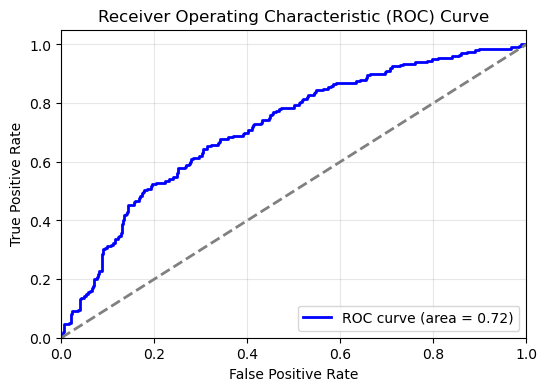

In [83]:
my_XGB(df_f,750,0.001,11,0.6,0.7,1.4)

Fitting 5 folds for each of 1728 candidates, totalling 8640 fits


C:\Users\ASUS\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [21:30:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Parameters:  {'colsample_bytree': 0.5, 'learning_rate': 0.005, 'max_depth': 5, 'n_estimators': 250, 'scale_pos_weight': 1.25, 'subsample': 0.75}
Best Cross-Validation Score:  0.671636859872154
Test Set:
Accuracy:  0.7160940325497287
Confusion Matrix:
 [[303  51]
 [106  93]]
PRFC:
 (array([0.7408313 , 0.64583333]), array([0.8559322 , 0.46733668]), array([0.79423329, 0.54227405]), array([354, 199], dtype=int64))


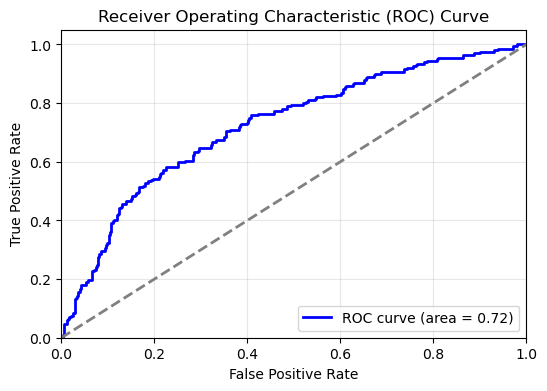

In [25]:
X_train, X_test, Y_train, Y_test = preprocess(df_f)
param_grid = {
    'n_estimators': [100, 250, 500, 1000],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.005, 0.01, 0.05, 0.2],
    'subsample': [0.5, 0.75, 1.0],
    'colsample_bytree': [0.5, 0.75, 1.0],
    'scale_pos_weight': [1.25, 1.5, 2]
}
model = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False, random_state=42)
grid_search = GridSearchCV(
    estimator=model,
    verbose=2,
    param_grid=param_grid,
    scoring=scoring,
    refit='auc',  
    cv=5,
    n_jobs=-1
)
grid_search.fit(X_train, Y_train)
print("Best Parameters: ", grid_search.best_params_)
print("Best Cross-Validation Score: ", grid_search.best_score_)
best_model = grid_search.best_estimator_
print("Test Set:")
Y_pred=best_model.predict(X_test)
print("Accuracy: ",skm.accuracy_score(Y_test,Y_pred))
print("Confusion Matrix:\n",confusion_matrix(Y_test,Y_pred))
print("PRFC:\n",skm.precision_recall_fscore_support(Y_test,Y_pred))
my_roc_auc(best_model,X_test,Y_test)

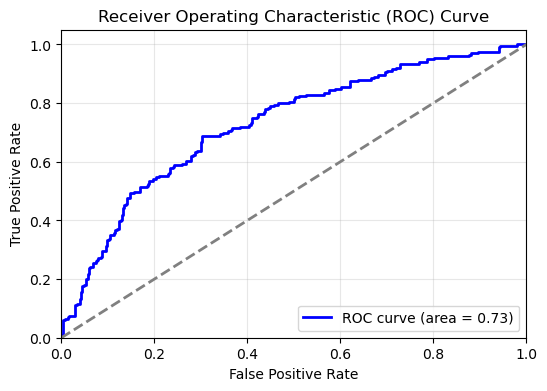

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.5, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None,
              num_parallel_tree=None, ...)

In [47]:
my_roc_auc(best_model,X_test,Y_test)
best_model